In [1]:
# importing required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Wholesale Customer Dataset

In [2]:
# reading csv file
df = pd.read_csv(r"C:\Users\agraw\OneDrive\Desktop\wholesale customer dataset.zip")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
# printing shape of dataset
df.shape

(440, 8)

In [4]:
# checking information about data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [5]:
# analysing some statistical information
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [6]:
# cheking for null values in dataset
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [7]:
# checking if duplicate values are present or not
df.duplicated().sum()

np.int64(0)

In [8]:
# selecting columns 
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

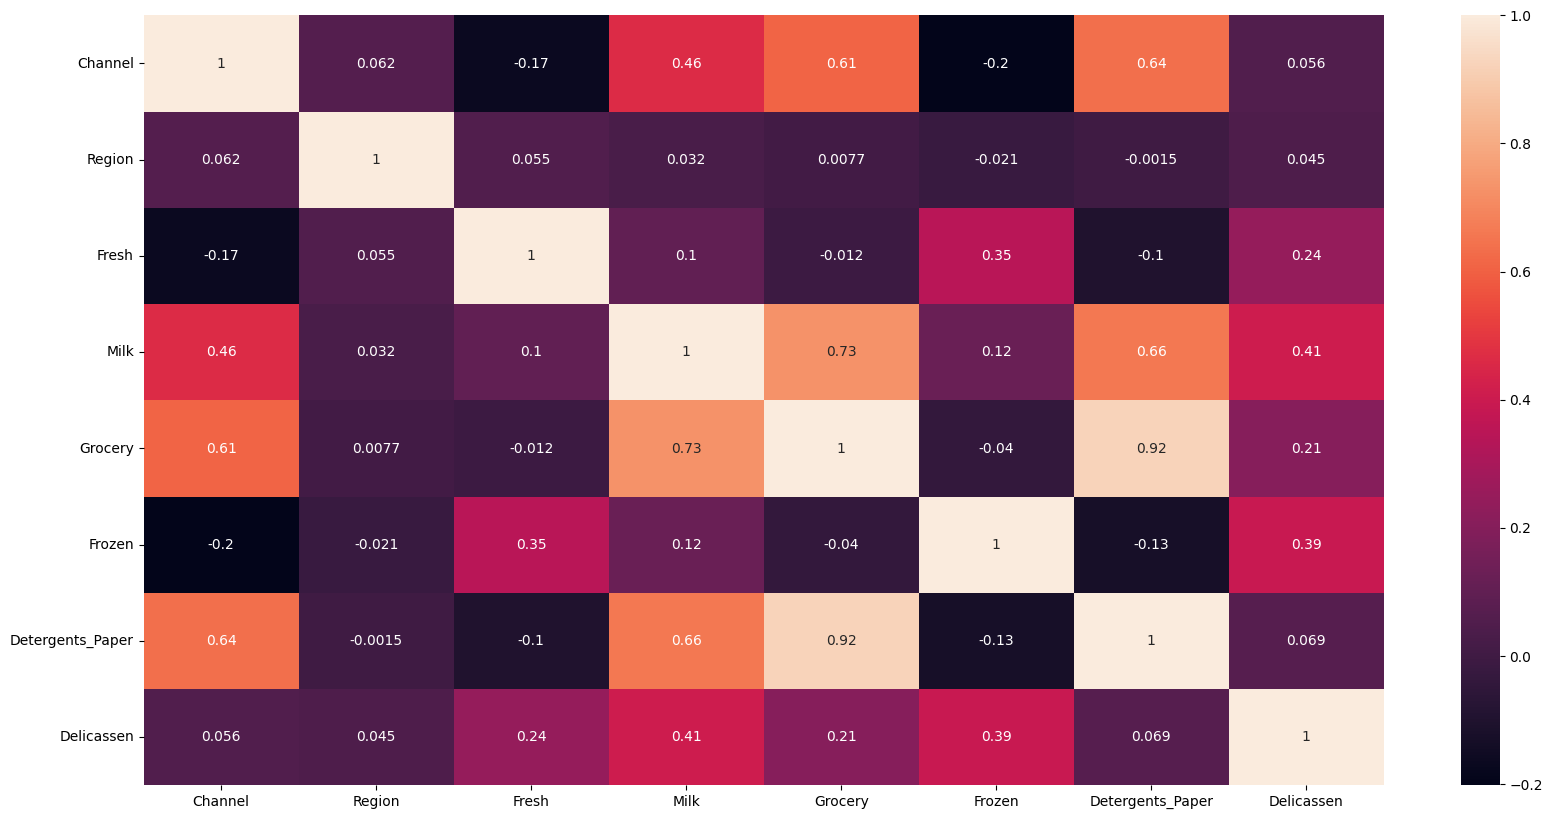

In [9]:
# plotting heatmap 
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(), annot = True)
plt.show()

In [10]:
#dropping column from dataset
df.drop(columns = "Region", inplace = True)

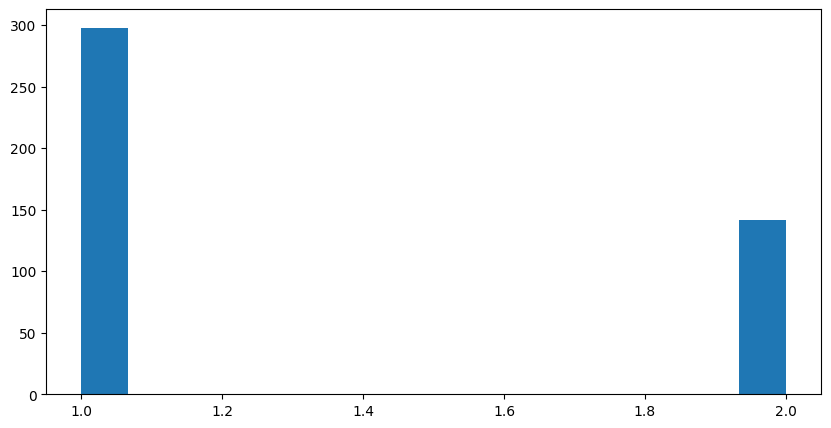

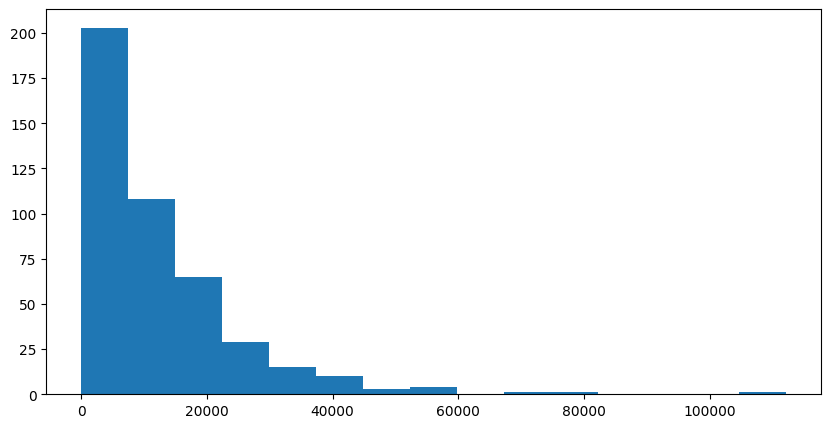

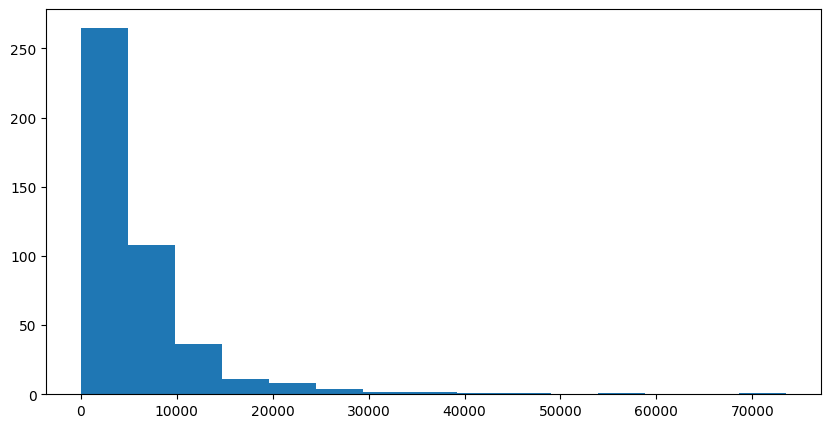

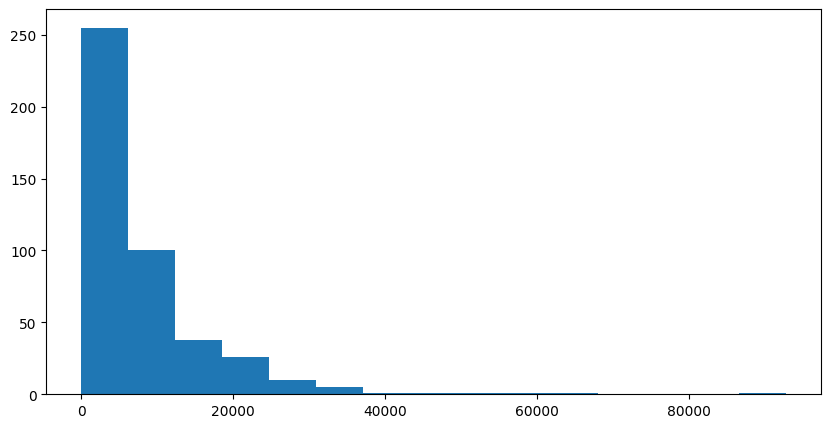

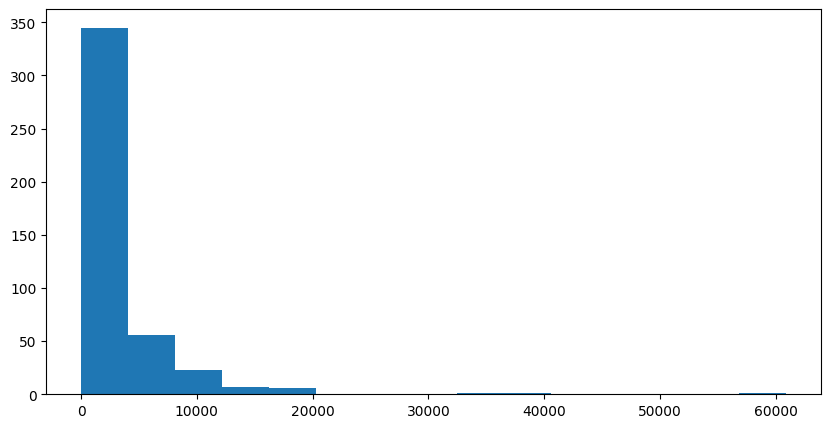

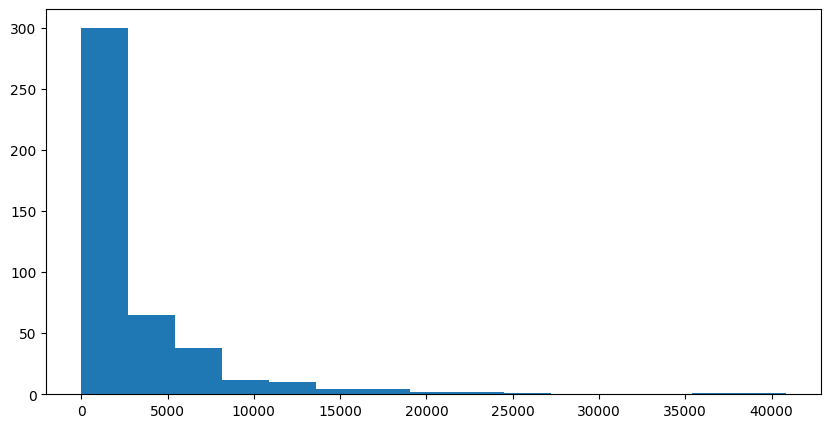

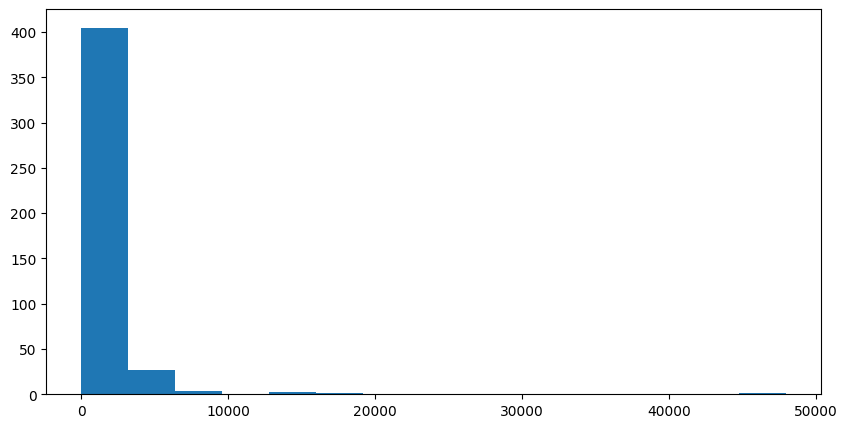

In [11]:
# histogram plotting
for i in df.columns:
    plt.figure(figsize = (10,5))
    plt.hist(df[i], bins = 15)
    plt.show()

In [12]:
# printing columns of dataset
df.columns

Index(['Channel', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper',
       'Delicassen'],
      dtype='object')

In [13]:
x = df[['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper',
       'Delicassen']]

In [14]:
# standardization
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
x_scale = scale.fit_transform(x)

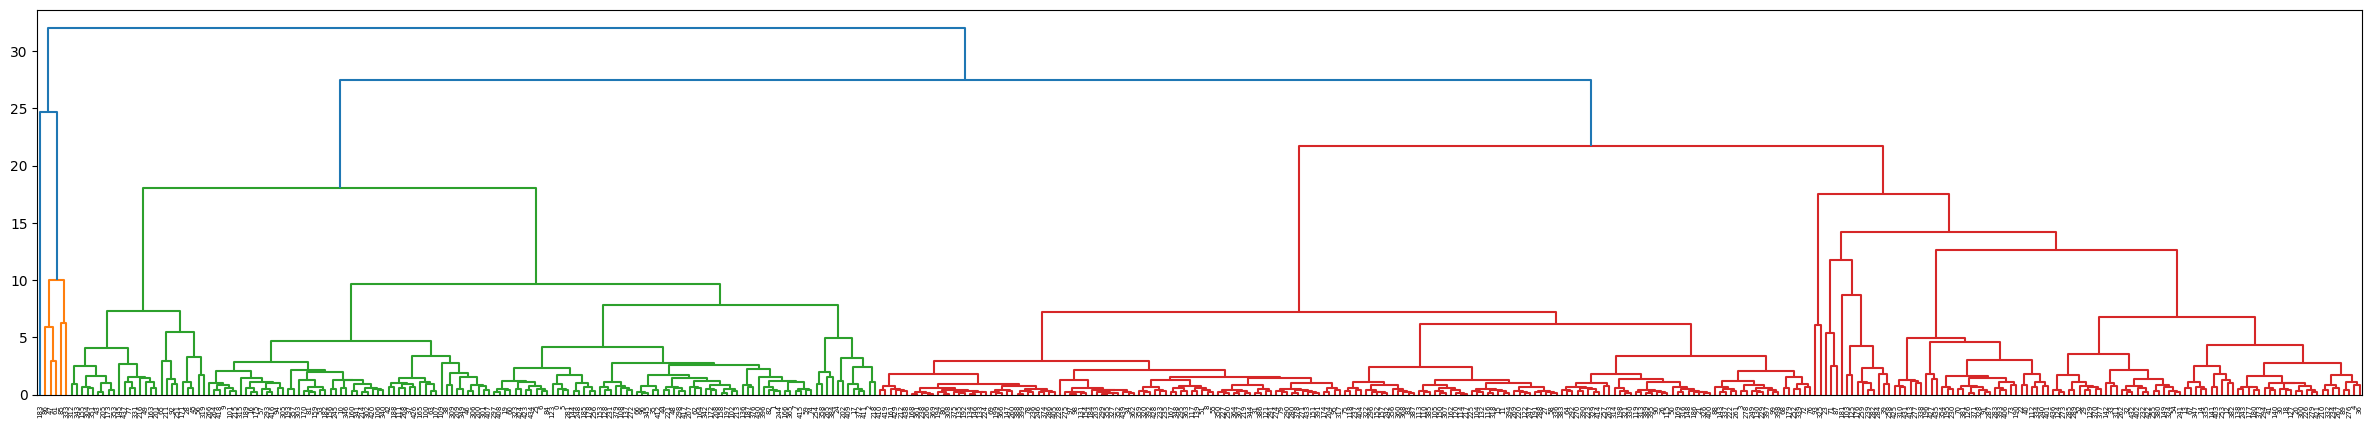

In [15]:
# plotting dandogram
from scipy.cluster.hierarchy import dendrogram, linkage
z = linkage(x_scale, method = "ward")
plt.figure(figsize = (30,5))
dendrogram(z)
plt.show()

In [16]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

for i in range(2,10):

    model = AgglomerativeClustering(n_clusters=i, linkage="ward")

    df["cluster"] = model.fit_predict(x_scale)
    print(df["cluster"].value_counts())

   
    score = silhouette_score(x_scale, df["cluster"])
    print(score)

cluster
0    434
1      6
Name: count, dtype: int64
0.7924572758342273
cluster
1    281
2    153
0      6
Name: count, dtype: int64
0.2646091480214908
cluster
0    281
2    153
1      5
3      1
Name: count, dtype: int64
0.2670148241989557
cluster
4    177
0    153
2    104
1      5
3      1
Name: count, dtype: int64
0.23988371669170097
cluster
4    177
2    127
0    104
5     26
1      5
3      1
Name: count, dtype: int64
0.23424990872738188
cluster
4    177
2    127
0    102
5     26
1      5
6      2
3      1
Name: count, dtype: int64
0.24405686464597856
cluster
4    177
2    127
0     89
5     26
1     13
3      5
6      2
7      1
Name: count, dtype: int64
0.2520384687343341
cluster
4    177
2    127
3     59
8     30
5     26
0     13
1      5
6      2
7      1
Name: count, dtype: int64
0.27202620570114383


In [17]:
# kmeans clustering
from sklearn.cluster import KMeans
c = []
for i in range(1, 11):
    model = KMeans(n_clusters = i, random_state = 42, n_init = 10)
    model.fit(x_scale)
    c.append(model.inertia_)

C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans 

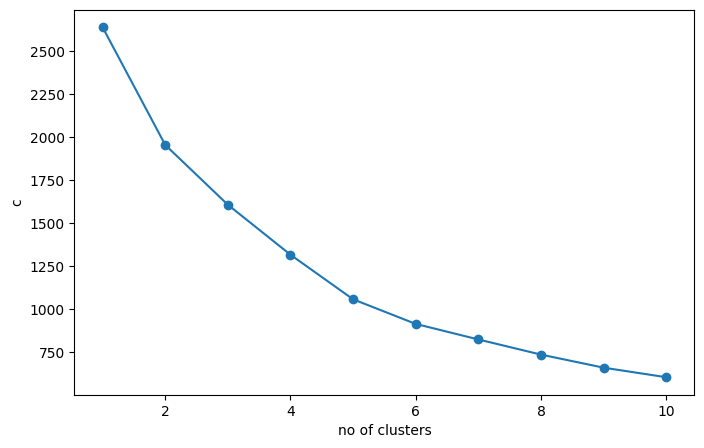

In [18]:
plt.figure(figsize = (8,5))
plt.plot(range(1,11), c, marker = "o")
plt.xlabel("no of clusters")
plt.ylabel("c")
plt.show()

In [19]:
# modelling of data 
for i in range(2, 10):
    model = KMeans(
        n_clusters = i, random_state = 42, n_init = 10
    )
    cluster = model.fit_predict(x_scale)
    df["cluster"] = cluster
    df["cluster"].unique(),df["cluster"].value_counts() 
    score = silhouette_score(x_scale, df["cluster"])
    print(score)

C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans 

0.5472146913441881
0.5482872649700601
0.34847138657014315
0.3690403826812808
0.3782288965882046
0.3342819788182625
0.3201161896109077
0.30902833452574485


C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [20]:

model = KMeans(
        n_clusters = 3, random_state = 42, n_init = 10
    )
cluster = model.fit_predict(x_scale)
df["cluster"] = cluster
df["cluster"].unique(),df["cluster"].value_counts() 
score = silhouette_score(x_scale, df["cluster"])
print(score)

C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


0.5482872649700601


In [21]:

model = KMeans(
        n_clusters = 2, random_state = 42, n_init = 10
    )
cluster = model.fit_predict(x_scale)
df["cluster"] = cluster
df["cluster"].unique(),df["cluster"].value_counts() 
score = silhouette_score(x_scale, df["cluster"])
print(score)

0.5472146913441881


C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [22]:
centeroid = scale.inverse_transform(model.cluster_centers_)
centeroid

array([[12157.30077121,  4028.16966581,  5402.72236504,  3066.06683805,
         1667.68894602,  1256.89460154],
       [10802.76470588, 19282.33333333, 27390.25490196,  3116.66666667,
        12139.7254902 ,  3568.84313725]])

In [23]:
# cheking if grouping is done in correct way or not by decisiontreeclassifier

from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(x_scale, test_size=0.20, random_state=42)

train_labels = model.predict(X_train)
test_labels = model.predict(X_test)
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, train_labels)
pred = dt.predict(X_test)
from sklearn.metrics import accuracy_score
acc = accuracy_score(test_labels, pred)
print("Accuracy:", acc*100)

Accuracy: 98.86363636363636


In [24]:
# cheking if grouping is done in correct way or not by logistic regression

from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(x_scale, test_size = 0.2, random_state= 42)
train_labels = model.predict(X_train)
test_labels = model.predict(X_test)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, train_labels)

pred = lr.predict(X_test)
from sklearn.metrics import accuracy_score
acc = accuracy_score(test_labels, pred)
print("Accuracy:", acc*100)

Accuracy: 97.72727272727273
